# Notebook 3 — Full Pipeline: BiomedCLIP + BLIP VQA + Report
Runs both models on an X-ray and generates a structured radiology-style report
from BiomedCLIP scores and BLIP VQA answers — no external API required.

In [1]:
import sys, os
sys.path.insert(0, '..')

from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import csv

from pipeline.report_generator import ReportGenerator

## 1. Load the full pipeline

In [2]:
generator = ReportGenerator()
print('Pipeline ready (BiomedCLIP + BLIP VQA, 15 conditions)')

Loading BiomedCLIP on cpu...


BiomedCLIP loaded.


Loading BLIP VQA on cpu...


The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


BlipForQuestionAnswering LOAD REPORT from: Salesforce/blip-vqa-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 
text_encoder.embeddings.position_ids      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BLIP VQA loaded.
Pipeline ready (BiomedCLIP + BLIP VQA, 15 conditions)


## 2. Run on all eval images

In [3]:
eval_dir = Path('../data/eval')
with open(eval_dir / 'labels.csv', encoding='utf-8') as f:
    all_samples = list(csv.DictReader(f))

# Use 5 diverse demo images
demo_labels = ['no finding', 'pneumonia', 'pleural effusion', 'cardiomegaly', 'tuberculosis']
samples = [next(s for s in all_samples if s['label'] == l) for l in demo_labels]
print(f'Will analyze {len(samples)} demo images')

Will analyze 5 demo images


In [4]:
all_results = []

for sample in samples:
    img_path = eval_dir / sample['filename']
    image = Image.open(img_path).convert('RGB')
    
    print(f"\n{'='*65}")
    print(f"Analyzing: {sample['filename']}  (true: {sample['label']})")
    print('='*65)
    
    result = generator.analyze(image)
    result['filename'] = sample['filename']
    result['true_label'] = sample['label']
    result['image'] = image
    all_results.append(result)
    
    pred = result['clip']['top_condition']
    score = result['clip']['top_score']
    correct = pred == sample['label']
    print(f"CLIP prediction: {pred} ({score:.1%})  {'✓' if correct else '✗'}")


Analyzing: eval_normal_01.jpg  (true: no finding)
Running BiomedCLIP classification...
Running BLIP VQA captioning...


Building report...
CLIP prediction: no finding (88.5%)  ✓

Analyzing: eval_pneumonia_01.jpg  (true: pneumonia)
Running BiomedCLIP classification...
Running BLIP VQA captioning...


Building report...
CLIP prediction: pleural effusion (80.7%)  ✗

Analyzing: eval_pleural_effusion_01.jpg  (true: pleural effusion)
Running BiomedCLIP classification...
Running BLIP VQA captioning...


Building report...
CLIP prediction: pneumothorax (68.7%)  ✗

Analyzing: eval_cardiomegaly_01.jpg  (true: cardiomegaly)
Running BiomedCLIP classification...
Running BLIP VQA captioning...


Building report...
CLIP prediction: mediastinal mass (18.8%)  ✗

Analyzing: eval_tuberculosis_01.jpg  (true: tuberculosis)
Running BiomedCLIP classification...
Running BLIP VQA captioning...


Building report...
CLIP prediction: tuberculosis (91.1%)  ✓


## 3. Display full reports

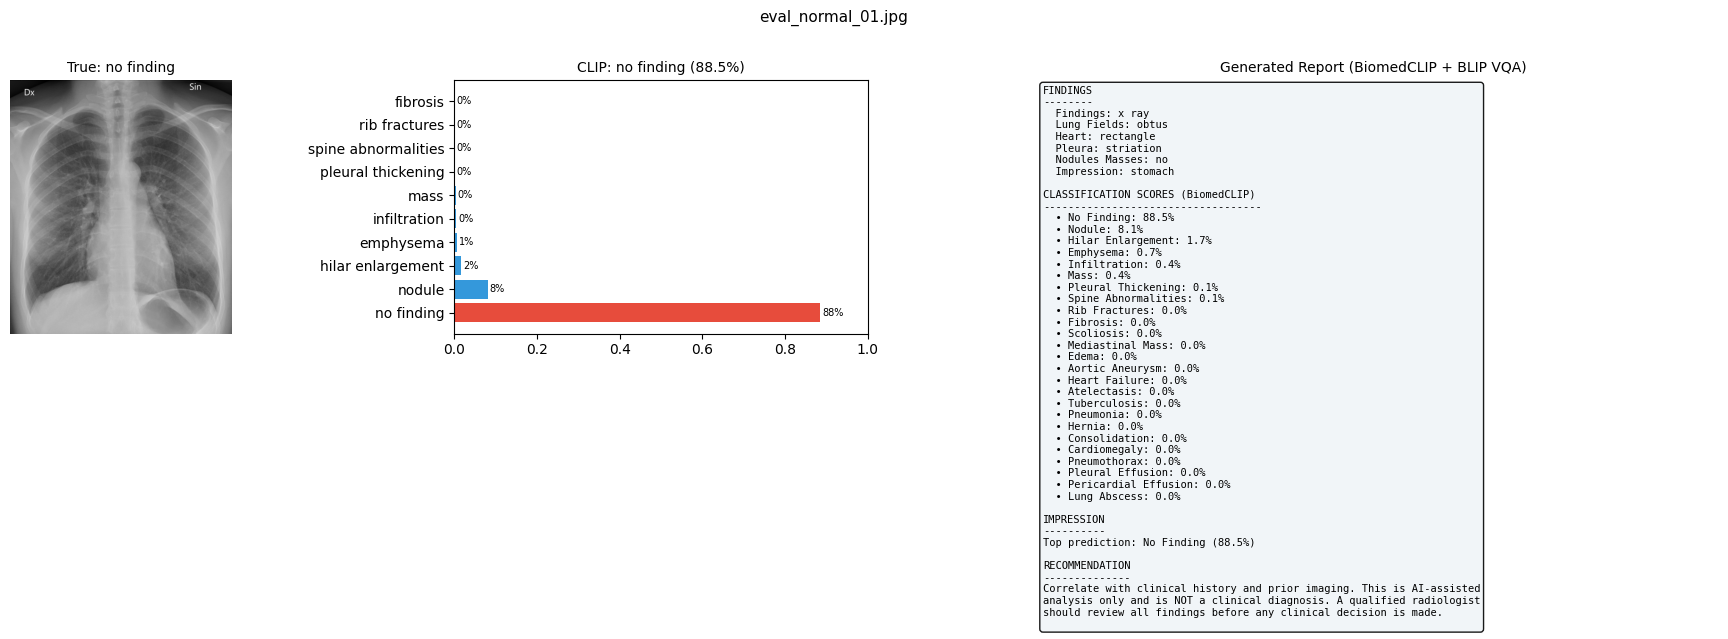

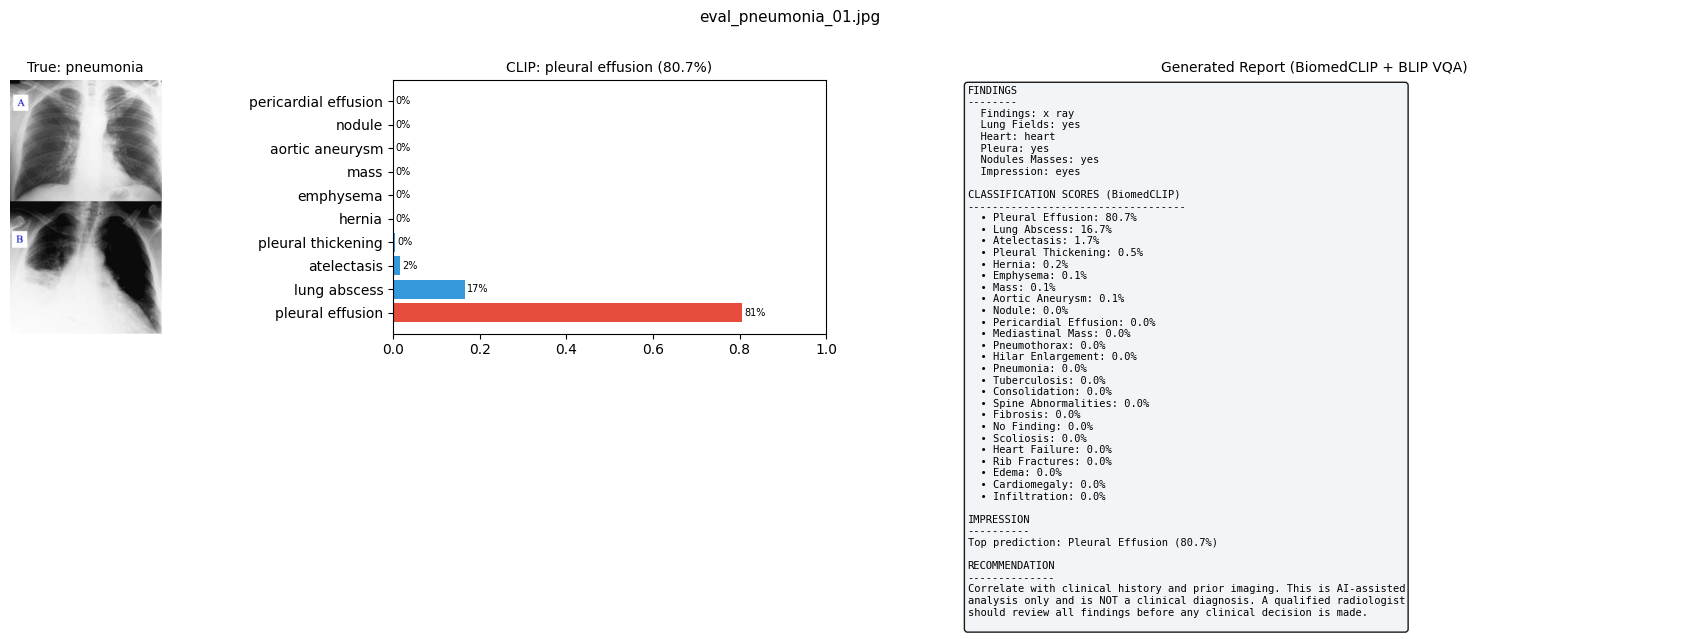

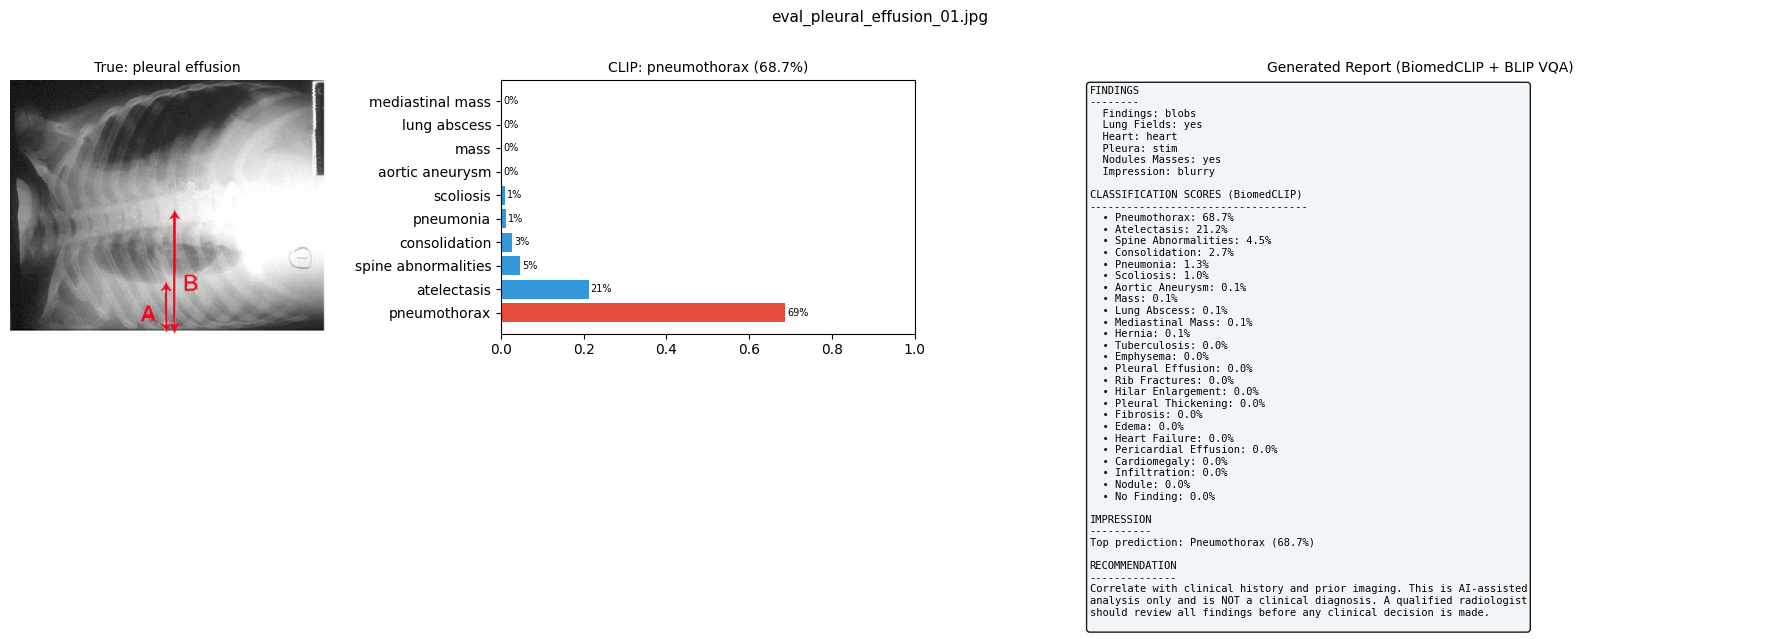

/var/folders/xl/h7p9qmt557vgrssq1g9w726r0000gn/T/ipykernel_33645/2297370012.py:32: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/Users/nityasreecheera/github/chest-xray-analyzer/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


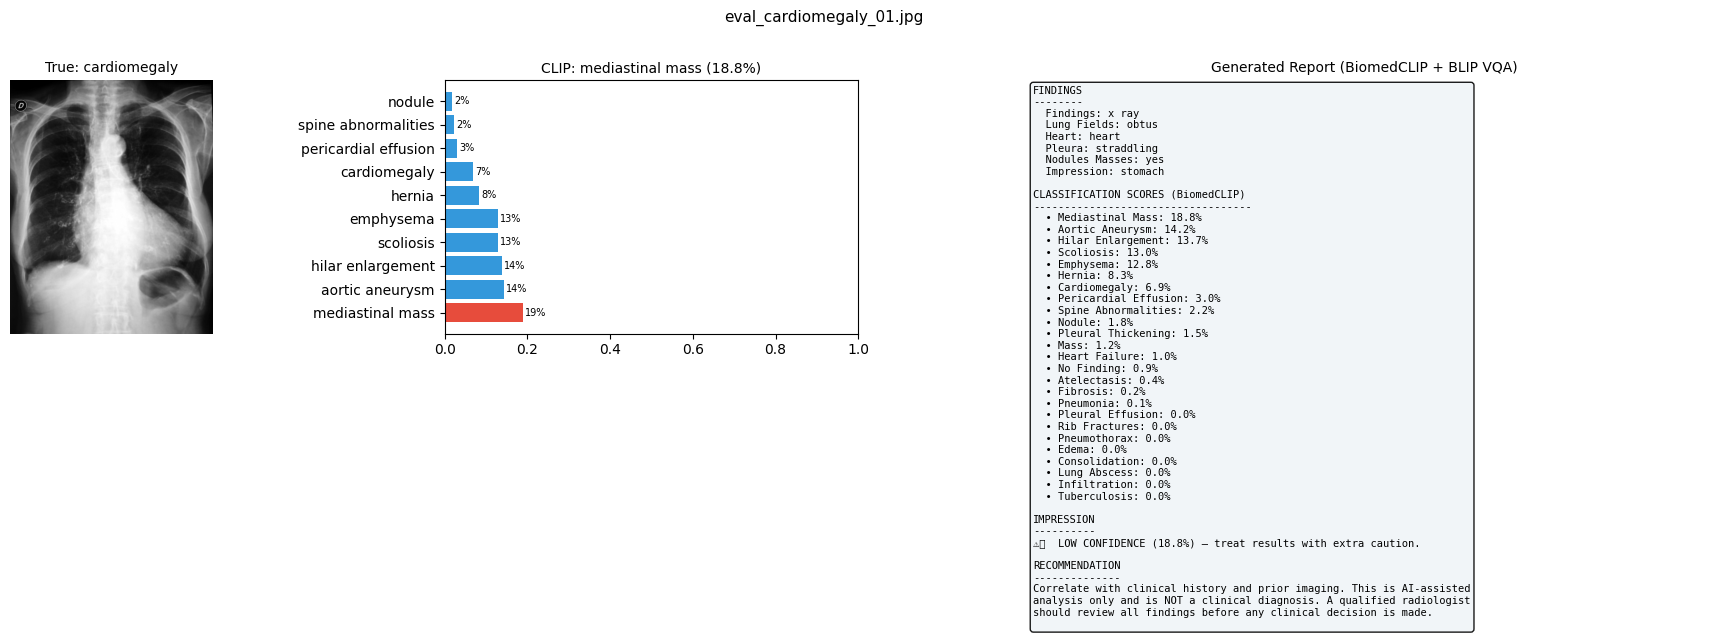

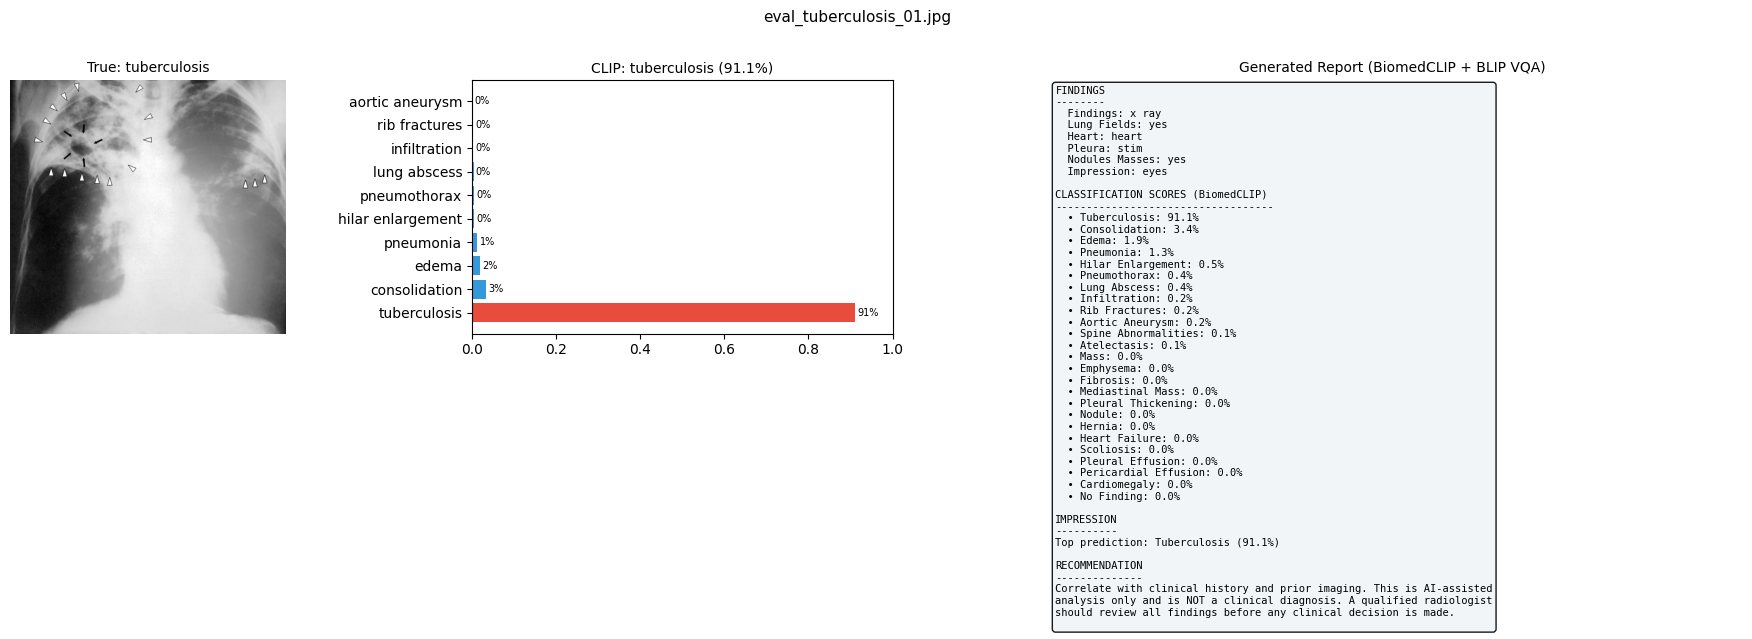

In [5]:
for r in all_results:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5),
                             gridspec_kw={'width_ratios': [1, 1.2, 2]})

    # Column 1: X-ray image
    axes[0].imshow(r['image'], cmap='gray')
    axes[0].set_title(f"True: {r['true_label']}", fontsize=10)
    axes[0].axis('off')

    # Column 2: CLIP scores bar chart
    scores = r['clip']['scores']
    # Show top 10 conditions for readability
    top_conditions = sorted(scores, key=scores.get, reverse=True)[:10]
    vals = [scores[c] for c in top_conditions]
    colors = ['#e74c3c' if c == r['clip']['top_condition'] else '#3498db' for c in top_conditions]
    bars = axes[1].barh(top_conditions, vals, color=colors)
    for bar, val in zip(bars, vals):
        axes[1].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                     f'{val:.0%}', va='center', fontsize=7)
    axes[1].set_xlim(0, 1)
    axes[1].set_title(f"CLIP: {r['clip']['top_condition']} ({r['clip']['top_score']:.1%})", fontsize=10)

    # Column 3: Report text
    axes[2].text(0.02, 0.98, r['report'], transform=axes[2].transAxes,
                 fontsize=7.5, va='top', family='monospace',
                 bbox=dict(boxstyle='round', facecolor='#f0f4f8', alpha=0.9),
                 wrap=True)
    axes[2].axis('off')
    axes[2].set_title('Generated Report (BiomedCLIP + BLIP VQA)', fontsize=10)

    plt.suptitle(r['filename'], fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()
    print()

## 4. Print all reports as plain text

In [6]:
for r in all_results:
    print(f"\n{'='*65}")
    print(f"FILE: {r['filename']}  |  True: {r['true_label']}  |  CLIP: {r['clip']['top_condition']} ({r['clip']['top_score']:.1%})")
    print('='*65)
    print(r['report'])


FILE: eval_normal_01.jpg  |  True: no finding  |  CLIP: no finding (88.5%)
FINDINGS
--------
  Findings: x ray
  Lung Fields: obtus
  Heart: rectangle
  Pleura: striation
  Nodules Masses: no
  Impression: stomach

CLASSIFICATION SCORES (BiomedCLIP)
-----------------------------------
  • No Finding: 88.5%
  • Nodule: 8.1%
  • Hilar Enlargement: 1.7%
  • Emphysema: 0.7%
  • Infiltration: 0.4%
  • Mass: 0.4%
  • Pleural Thickening: 0.1%
  • Spine Abnormalities: 0.1%
  • Rib Fractures: 0.0%
  • Fibrosis: 0.0%
  • Scoliosis: 0.0%
  • Mediastinal Mass: 0.0%
  • Edema: 0.0%
  • Aortic Aneurysm: 0.0%
  • Heart Failure: 0.0%
  • Atelectasis: 0.0%
  • Tuberculosis: 0.0%
  • Pneumonia: 0.0%
  • Hernia: 0.0%
  • Consolidation: 0.0%
  • Cardiomegaly: 0.0%
  • Pneumothorax: 0.0%
  • Pleural Effusion: 0.0%
  • Pericardial Effusion: 0.0%
  • Lung Abscess: 0.0%

IMPRESSION
----------
Top prediction: No Finding (88.5%)

RECOMMENDATION
--------------
Correlate with clinical history and prior imaging. 